In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Weergave-instellingen
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
# Dataset laden
df = pd.read_csv('../data/energydata_complete.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 1. Dataset Beschrijving

**Dataset:** Appliances Energy Prediction  
**Bron:** UCI Machine Learning Repository  
**Link:** https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

**Wat wordt voorspeld?**  
Het energieverbruik van huishoudelijke apparaten (`Appliances`), gemeten in Wh (wattuur).

**Waarom is deze dataset geschikt voor regressie?**  
- De target variabele `Appliances` is continu (numeriek, niet categoriaal)
- De dataset bevat 19.735 rijen 
- Er zijn 29 kolommen, waarvan minstens 10 bruikbaar als onafhankelijke variabelen
- De onafhankelijke variabelen (temperatuur, luchtvochtigheid, windsnelheid, etc.) zijn logische voorspellers van energieverbruik
- De dataset komt niet van Kaggle

## 2. Data Dictionary

| Variabele | Beschrijving | Type |
|-----------|-------------|------|
| date | Datum en tijd van de meting | Datum |
| **Appliances** | **Energieverbruik van apparaten in Wh (TARGET)** | **Continu** |
| lights | Energieverbruik van verlichting in Wh | Continu |
| T1 - T9 | Temperatuur in verschillende kamers (°C) | Continu |
| RH_1 - RH_9 | Luchtvochtigheid in verschillende kamers (%) | Continu |
| T_out | Buitentemperatuur (°C) | Continu |
| Press_mm_hg | Luchtdruk (mmHg) | Continu |
| RH_out | Luchtvochtigheid buiten (%) | Continu |
| Windspeed | Windsnelheid (m/s) | Continu |
| Visibility | Zichtbaarheid (km) | Continu |
| Tdewpoint | Dauwpunt temperatuur (°C) | Continu |
| rv1 | Willekeurige variabele 1 | Continu |
| rv2 | Willekeurige variabele 2 | Continu |

In [4]:
# Datatypes en ontbrekende waarden bekijken
print("Datatypes:")
print(df.dtypes)
print(f"\nOntbrekende waarden per kolom:")
print(df.isnull().sum())
print(f"\nTotaal ontbrekende waarden: {df.isnull().sum().sum()}")

Datatypes:
date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object

Ontbrekende waarden per kolom:
date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7

### Bevinding: Ontbrekende waarden

De dataset bevat **geen ontbrekende waarden**. Er is dus geen imputatie of verwijdering nodig. 
We kunnen de data direct gebruiken voor verdere analyse.

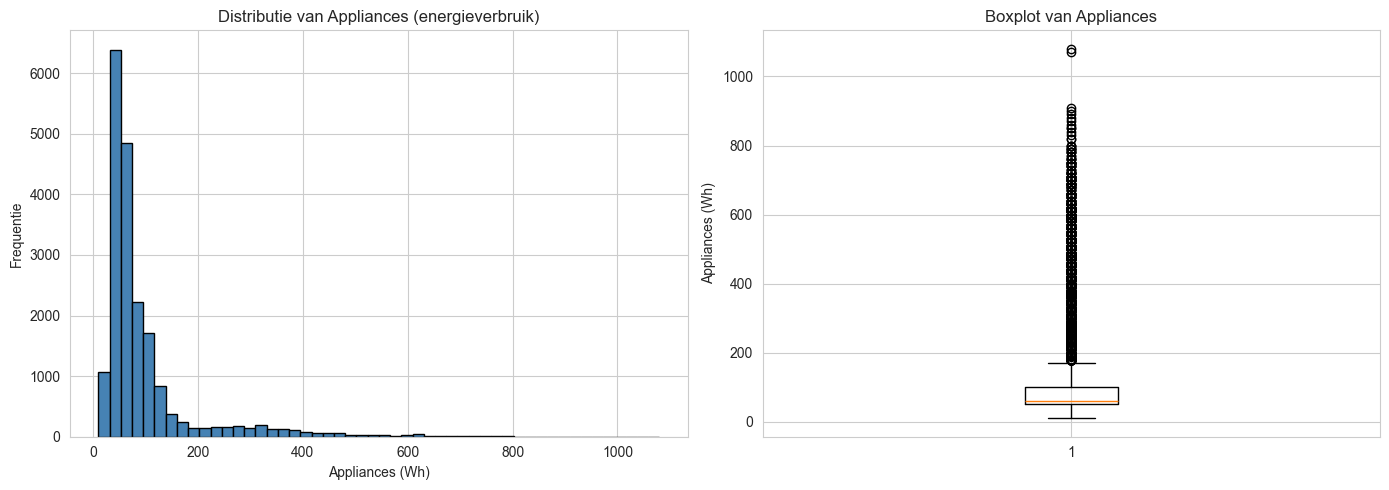

Gemiddelde: 97.69 Wh
Mediaan: 60.00 Wh
Std: 102.52 Wh
Min: 10 Wh
Max: 1080 Wh


In [5]:
# Distributie van de target variabele (Appliances)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Appliances'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Distributie van Appliances (energieverbruik)')
axes[0].set_xlabel('Appliances (Wh)')
axes[0].set_ylabel('Frequentie')

# Boxplot
axes[1].boxplot(df['Appliances'], vert=True)
axes[1].set_title('Boxplot van Appliances')
axes[1].set_ylabel('Appliances (Wh)')

plt.tight_layout()
plt.show()

print(f"Gemiddelde: {df['Appliances'].mean():.2f} Wh")
print(f"Mediaan: {df['Appliances'].median():.2f} Wh")
print(f"Std: {df['Appliances'].std():.2f} Wh")
print(f"Min: {df['Appliances'].min()} Wh")
print(f"Max: {df['Appliances'].max()} Wh")

### Bevinding: Distributie van Appliances

De target variabele is **sterk rechts-scheef**: de meeste metingen liggen tussen 10 en 100 Wh, 
maar er zijn uitschieters tot 1080 Wh. Het verschil tussen het gemiddelde (97.69 Wh) en de 
mediaan (60.00 Wh) bevestigt deze scheefheid.

De boxplot laat veel **outliers** zien aan de bovenkant. Dit zijn momenten van hoog energieverbruik. 
We verwijderen deze niet zomaar — ze kunnen inhoudelijk betekenisvol zijn (bijvoorbeeld 
piekverbruik). We houden hier later rekening mee bij de modelkeuze.

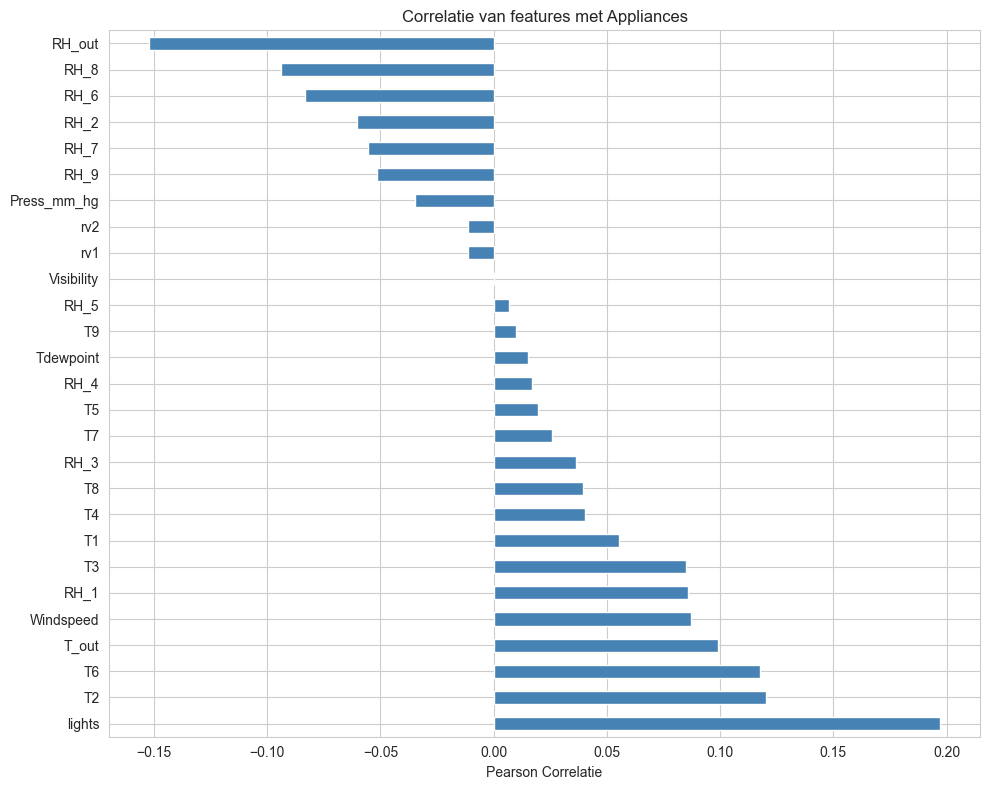

Top 5 positieve correlaties:
lights       0.197278
T2           0.120073
T6           0.117638
T_out        0.099155
Windspeed    0.087122
Name: Appliances, dtype: float64

Top 5 negatieve correlaties:
RH_7     -0.055642
RH_2     -0.060465
RH_6     -0.083178
RH_8     -0.094039
RH_out   -0.152282
Name: Appliances, dtype: float64


In [6]:
# Correlatie van alle numerieke variabelen met Appliances
correlations = df.select_dtypes(include=[np.number]).corr()['Appliances'].drop('Appliances').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color='steelblue')
plt.title('Correlatie van features met Appliances')
plt.xlabel('Pearson Correlatie')
plt.tight_layout()
plt.show()

print("Top 5 positieve correlaties:")
print(correlations.head())
print("\nTop 5 negatieve correlaties:")
print(correlations.tail())

### Bevinding: Correlatie met Appliances

De correlaties met de target variabele zijn **over het algemeen zwak**. De sterkste correlaties zijn:

**Positief:**
- `lights` (0.20) — verlichting hangt logisch samen met apparaatgebruik
- `T2` (0.12) en `T6` (0.12) — kamertemperaturen

**Negatief:**
- `RH_out` (-0.15) — buitenluchtvochtigheid
- `RH_8` (-0.09) — luchtvochtigheid in kamer 8

**Opmerking:** Geen enkele feature heeft een sterke lineaire correlatie met Appliances (alle |r| < 0.20). 
Dit betekent dat een enkel lineair model mogelijk beperkt presteert, en dat we later modellen 
moeten proberen die ook niet-lineaire relaties kunnen vangen.

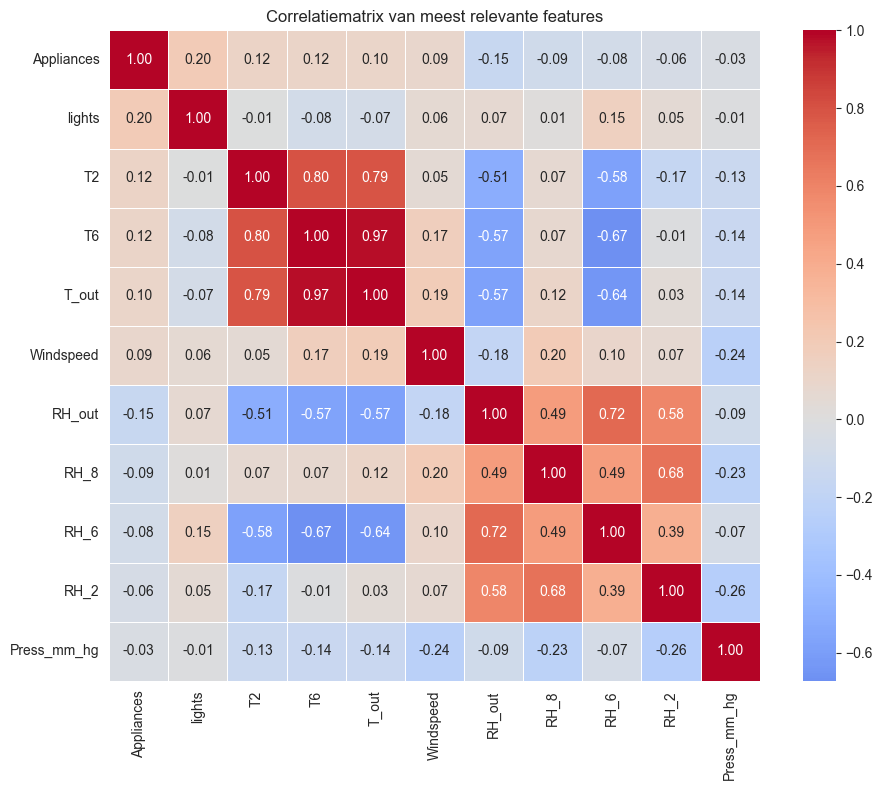

In [7]:
# Heatmap van alleen de meest relevante features met Appliances
top_features = ['Appliances', 'lights', 'T2', 'T6', 'T_out', 'Windspeed', 
                'RH_out', 'RH_8', 'RH_6', 'RH_2', 'Press_mm_hg']

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlatiematrix van meest relevante features')
plt.tight_layout()
plt.show()

### Bevinding: Multicollinearity tussen features

De heatmap laat sterke onderlinge correlaties zien tussen features:

**Temperaturen:**
- `T6` en `T_out`: **0.97** — bijna identiek
- `T2` en `T6`: **0.80**
- `T2` en `T_out`: **0.79**

**Luchtvochtigheid:**
- `RH_out` en `RH_6`: **0.72**
- `RH_8` en `RH_2`: **0.68**

Dit wijst op **multicollinearity**: meerdere features meten vrijwel hetzelfde. 
Volgens de theorie (VIF > 10 = probleem) moeten we hier later bij feature selection 
rekening mee houden. We zullen overtollige features moeten verwijderen om de 
regressiecoëfficiënten betrouwbaar te houden.

## 3. Preprocessing

### Stap 1: Controleren van rv1 en rv2

De kolommen `rv1` en `rv2` worden gecontroleerd op hun bruikbaarheid als voorspellers. 
Volgens de UCI-documentatie zijn dit willekeurig gegenereerde variabelen. We verifiëren dit.

rv1 beschrijving:
count    19735.000000
mean        24.988033
std         14.496634
min          0.005322
25%         12.497889
50%         24.897653
75%         37.583769
max         49.996530
Name: rv1, dtype: float64

Correlatie rv1 met Appliances: -0.0111
Correlatie rv2 met Appliances: -0.0111


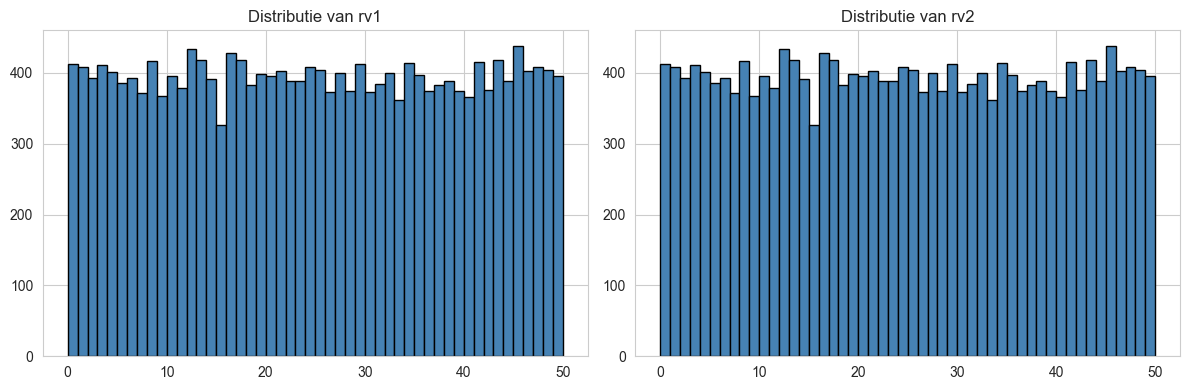

In [8]:
# Check rv1 en rv2: zijn dit echte variabelen of random ruis?
print("rv1 beschrijving:")
print(df['rv1'].describe())
print(f"\nCorrelatie rv1 met Appliances: {df['rv1'].corr(df['Appliances']):.4f}")
print(f"Correlatie rv2 met Appliances: {df['rv2'].corr(df['Appliances']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['rv1'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distributie van rv1')
axes[1].hist(df['rv2'], bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('Distributie van rv2')
plt.tight_layout()
plt.show()

### Bevinding: rv1 en rv2

Beide variabelen hebben een correlatie van -0.01 met Appliances — praktisch nul. 
De beschrijvende statistieken (min ≈ 0, max ≈ 50, gemiddelde ≈ 25) en de uniforme verdeling 
bevestigen dat dit willekeurig gegenereerde variabelen zijn zonder voorspelkracht. 
Ze worden verwijderd.

In [9]:
# rv1 en rv2 verwijderen — bevestigd als random variabelen zonder voorspelkracht
df = df.drop(columns=['rv1', 'rv2'])
print(f"Shape na verwijderen rv1/rv2: {df.shape}")

Shape na verwijderen rv1/rv2: (19735, 27)


### Stap 2: Feature engineering uit de date-kolom

De `date`-kolom is een string en kan niet direct als feature in regressie gebruikt worden. 
We extraheren het uur, de dag van de week en de maand als aparte numerieke features. 
Deze kunnen invloed hebben op energieverbruik (bijvoorbeeld meer verbruik overdag dan 's nachts).

In [10]:
# Datum omzetten naar datetime en tijdfeatures extraheren
df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek  # 0=maandag, 6=zondag
df['month'] = df['date'].dt.month

# Originele date-kolom verwijderen
df = df.drop(columns=['date'])

print(f"Shape na feature engineering: {df.shape}")
print(f"\nVoorbeeld van nieuwe features:")
df[['hour', 'day_of_week', 'month']].head(10)

Shape na feature engineering: (19735, 29)

Voorbeeld van nieuwe features:


,hour,day_of_week,month
0,17,0,1
1,17,0,1
2,17,0,1
3,17,0,1
4,17,0,1
5,17,0,1
6,18,0,1
7,18,0,1
8,18,0,1
9,18,0,1


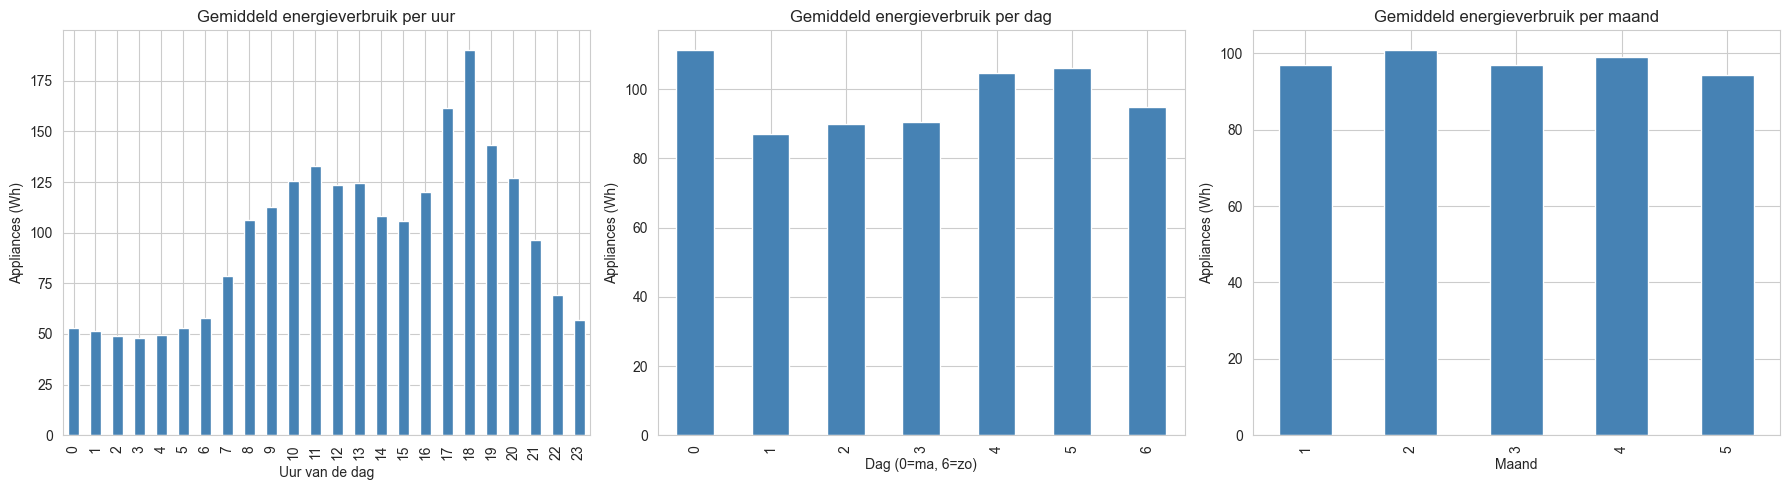

In [11]:
# Gemiddeld energieverbruik per uur, dag en maand
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df.groupby('hour')['Appliances'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Gemiddeld energieverbruik per uur')
axes[0].set_xlabel('Uur van de dag')
axes[0].set_ylabel('Appliances (Wh)')

df.groupby('day_of_week')['Appliances'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Gemiddeld energieverbruik per dag')
axes[1].set_xlabel('Dag (0=ma, 6=zo)')
axes[1].set_ylabel('Appliances (Wh)')

df.groupby('month')['Appliances'].mean().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Gemiddeld energieverbruik per maand')
axes[2].set_xlabel('Maand')
axes[2].set_ylabel('Appliances (Wh)')

plt.tight_layout()
plt.show()

### Bevinding: Tijdfeatures en energieverbruik

**Per uur:** Er is een duidelijk patroon. Het verbruik is laag 's nachts (0:00–6:00, ~50 Wh) 
en piekt rond 17:00–18:00 (~190 Wh). Dit komt overeen met de momenten dat bewoners thuis zijn 
en koken/apparaten gebruiken. Het uur is een waardevolle voorspeller.

**Per dag:** Maandag (0) en donderdag (3) hebben het hoogste verbruik (~110-115 Wh), 
dinsdag en zondag het laagste (~85-90 Wh). Er is enig verschil, maar minder uitgesproken dan bij het uur.

**Per maand:** Het verbruik is vrij stabiel per maand (range ~90-105 Wh). 
De maand voegt mogelijk minder voorspelkracht toe dan het uur.

**Conclusie:** Vooral `hour` is een sterke feature. `day_of_week` heeft enig effect. 
`month` voegt weinig toe maar we houden hem voorlopig in de dataset.

## 4. Feature Selection

### Stap 1: Multicollinearity check met VIF

We berekenen de Variance Inflation Factor (VIF) voor elke feature. 
Volgens de lesstof geldt:
- VIF > 10 → feature verwijderen (te veel multicollinearity)
- VIF rond 5 → acceptabel, maar in de gaten houden
- VIF < 5 → geen probleem

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Features klaarzetten (alles behalve de target)
X = df.drop(columns=['Appliances'])

# VIF berekenen voor elke feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("VIF-waarden per feature:")
print(vif_data.to_string(index=False))

VIF-waarden per feature:
    Feature         VIF
         T1 3697.050126
         T9 2935.737490
         T2 2507.817720
       RH_2 2173.192395
Press_mm_hg 2167.216266
       RH_1 1675.697333
         T7 1647.401311
       RH_3 1594.717237
       RH_4 1447.892438
     RH_out 1404.426886
         T3 1266.663157
         T5 1199.564863
         T4 1064.270082
         T8 1010.992900
       RH_9  690.668542
       RH_8  640.743627
       RH_7  520.332915
      T_out  426.818197
  Tdewpoint  135.099749
         T6   91.427120
      month   78.533670
       RH_6   49.534955
       RH_5   45.982107
 Visibility   12.115282
       hour    7.956139
  Windspeed    5.398081
day_of_week    3.592042
     lights    1.602075


### Stap 2: Iteratief features verwijderen op basis van VIF

We verwijderen steeds de feature met de hoogste VIF en herberekenen, 
tot alle overgebleven features een VIF < 10 hebben.

In [13]:
# Iteratief features verwijderen tot alle VIF < 10
X_vif = df.drop(columns=['Appliances']).copy()
removed_features = []

while True:
    vif_values = pd.DataFrame()
    vif_values['Feature'] = X_vif.columns
    vif_values['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    vif_values = vif_values.sort_values('VIF', ascending=False).reset_index(drop=True)
    
    max_vif = vif_values['VIF'].max()
    
    if max_vif < 10:
        break
    
    worst_feature = vif_values.loc[vif_values['VIF'].idxmax(), 'Feature']
    removed_features.append((worst_feature, round(max_vif, 2)))
    X_vif = X_vif.drop(columns=[worst_feature])
    
print(f"Verwijderde features ({len(removed_features)}):")
for feat, vif in removed_features:
    print(f"  {feat}: VIF = {vif}")

print(f"\nOvergebleven features ({len(X_vif.columns)}):")
print(vif_values.to_string(index=False))

Verwijderde features (21):
  T1: VIF = 3697.05
  T9: VIF = 2845.45
  Press_mm_hg: VIF = 2159.06
  RH_2: VIF = 1690.1
  RH_3: VIF = 1557.62
  RH_4: VIF = 1239.82
  T7: VIF = 1149.04
  T3: VIF = 970.62
  T5: VIF = 860.98
  T4: VIF = 664.68
  RH_9: VIF = 554.39
  RH_8: VIF = 472.93
  RH_out: VIF = 434.36
  T8: VIF = 352.66
  RH_1: VIF = 277.44
  T2: VIF = 238.48
  RH_7: VIF = 112.78
  T_out: VIF = 71.15
  RH_5: VIF = 30.42
  T6: VIF = 13.93
  Visibility: VIF = 10.48

Overgebleven features (7):
    Feature      VIF
      month 4.757840
       hour 3.757843
  Windspeed 3.631341
day_of_week 3.209390
       RH_6 3.110899
  Tdewpoint 2.398720
     lights 1.394613


### Bevinding: VIF Feature Selection

Van de 27 features zijn er 21 verwijderd vanwege multicollinearity (VIF > 10). 
Dit is logisch: de dataset bevat 9 temperatuursensoren en 9 luchtvochtigheidssensoren 
in verschillende kamers, die grotendeels hetzelfde meten.

**Overgebleven features (7):**
- `lights` — energieverbruik verlichting (VIF: 1.39)
- `Tdewpoint` — dauwpunttemperatuur (VIF: 2.40)
- `RH_6` — luchtvochtigheid kamer 6 (VIF: 3.11)
- `day_of_week` — dag van de week (VIF: 3.21)
- `Windspeed` — windsnelheid (VIF: 3.63)
- `hour` — uur van de dag (VIF: 3.76)
- `month` — maand (VIF: 4.76)

Alle VIF-waarden liggen ruim onder 10. Er is geen multicollinearity meer 
aanwezig tussen de overgebleven features.

### Stap 3: Pairwise Regression

We voeren voor elke overgebleven feature een enkelvoudige lineaire regressie uit 
tegen de target (`Appliances`). Dit toont de individuele voorspelkracht van elke feature.

In [14]:
# Pairwise regression: elke feature apart als voorspeller
selected_features = ['lights', 'Tdewpoint', 'RH_6', 'day_of_week', 'Windspeed', 'hour', 'month']

pairwise_results = []

for feature in selected_features:
    X_single = df[[feature]]
    y = df['Appliances']
    
    model = LinearRegression()
    model.fit(X_single, y)
    y_pred = model.predict(X_single)
    
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    pairwise_results.append({
        'Feature': feature,
        'R²': round(r2, 4),
        'RMSE': round(rmse, 2),
        'Coëfficiënt': round(model.coef_[0], 4)
    })

pairwise_df = pd.DataFrame(pairwise_results).sort_values('R²', ascending=False).reset_index(drop=True)
print("Pairwise Regression Resultaten:")
print(pairwise_df.to_string(index=False))

Pairwise Regression Resultaten:
    Feature     R²   RMSE  Coëfficiënt
       hour 0.0470 100.08       3.2110
     lights 0.0389 100.51       2.5486
  Windspeed 0.0076 102.13       3.6440
       RH_6 0.0069 102.17      -0.2738
  Tdewpoint 0.0002 102.51       0.3753
      month 0.0001 102.52      -0.8885
day_of_week 0.0000 102.52       0.1580


### Bevinding: Pairwise Regression

Geen enkele feature verklaart individueel veel variatie in energieverbruik. 
De beste individuele voorspellers zijn:

- `hour` (R² = 0.047) — het uur van de dag verklaart ongeveer 5% van de variatie
- `lights` (R² = 0.039) — verlichtingsverbruik verklaart ongeveer 4%

De overige features hebben individueel vrijwel geen lineaire voorspelkracht (R² < 0.01).

**Conclusie:** De lage individuele R²-waarden bevestigen dat we meerdere features 
samen nodig hebben, en dat niet-lineaire modellen waarschijnlijk beter presteren 
dan enkelvoudige lineaire regressie.

## 5. Modellering

### Stap 1: Train/Test Split

We splitsen de data in 80% training en 20% test. We gebruiken alleen de 7 overgebleven 
features na de VIF-analyse. De split wordt gedaan met een vaste random_state zodat 
de resultaten reproduceerbaar zijn.

In [15]:
# Features en target definiëren
selected_features = ['lights', 'Tdewpoint', 'RH_6', 'day_of_week', 'Windspeed', 'hour', 'month']

X = df[selected_features]
y = df['Appliances']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rijen")
print(f"Test set:     {X_test.shape[0]} rijen")

Training set: 15788 rijen
Test set:     3947 rijen


### Stap 2: Drie regressiemodellen trainen

We trainen en vergelijken drie modellen:

1. **Linear Regression** — als baseline, simpelste model
2. **Random Forest Regressor** — kan niet-lineaire relaties vangen
3. **Gradient Boosting Regressor** — krachtig ensemble-model dat stap voor stap leert

We evalueren elk model op de **testset** met R² en RMSE.

In [16]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Drie modellen definiëren
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Elk model trainen en evalueren
results = []

for name, model in models.items():
    # Trainen op trainingsdata
    model.fit(X_train, y_train)
    
    # Voorspellen op testdata
    y_pred = model.predict(X_test)
    
    # Evaluatiemetrics berekenen
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        'Model': name,
        'R²': round(r2, 4),
        'RMSE': round(rmse, 2)
    })
    
    print(f"{name}:")
    print(f"  R² = {r2:.4f}")
    print(f"  RMSE = {rmse:.2f}")
    print()

# Vergelijkingstabel
results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print("Vergelijkingstabel:")
print(results_df.to_string(index=False))

Linear Regression:
  R² = 0.0957
  RMSE = 95.13

Random Forest:
  R² = 0.5446
  RMSE = 67.51

Gradient Boosting:
  R² = 0.2592
  RMSE = 86.10

Vergelijkingstabel:
            Model     R²  RMSE
    Random Forest 0.5446 67.51
Gradient Boosting 0.2592 86.10
Linear Regression 0.0957 95.13


### Bevinding: Modelvergelijking

| Model | R² | RMSE |
|-------|-----|------|
| Random Forest | 0.5446 | 67.51 |
| Gradient Boosting | 0.2592 | 86.10 |
| Linear Regression | 0.0957 | 95.13 |

**Interpretatie:**

- **Linear Regression** presteert slecht (R² = 0.10). Dit bevestigt onze eerdere bevinding 
  dat de relaties tussen features en target niet lineair zijn.
- **Gradient Boosting** doet het beter (R² = 0.26), maar verklaart nog steeds weinig variatie.
- **Random Forest** presteert het best (R² = 0.54, RMSE = 67.51). Dit model verklaart 
  ~54% van de variatie in energieverbruik en heeft de laagste voorspelfout.

**Waarom Random Forest het best presteert:**
Random Forest kan niet-lineaire relaties en interacties tussen features vangen, 
wat belangrijk is bij deze dataset waar individuele lineaire correlaties zwak zijn. 
Het model combineert meerdere beslisbomen die elk verschillende patronen leren.
Het Random Forest model heeft een RMSE van 67.51 Wh. 
Dit betekent dat de voorspelling gemiddeld ~68 Wh afwijkt van het werkelijke energieverbruik. 
Het gemiddelde verbruik in de dataset is ~98 Wh — de fout is dus aanzienlijk, 
maar dit is het beste resultaat van de drie modellen

**Conclusie:** Random Forest is het beste model voor deze dataset.

## 6. Residual Analysis

We analyseren de residuals van het beste model (Random Forest) om te controleren op:
- Patronen in de residuals (lineariteit)
- Gelijke spreiding van fouten (Homoscedasticity)
- Normaliteit van de fouten

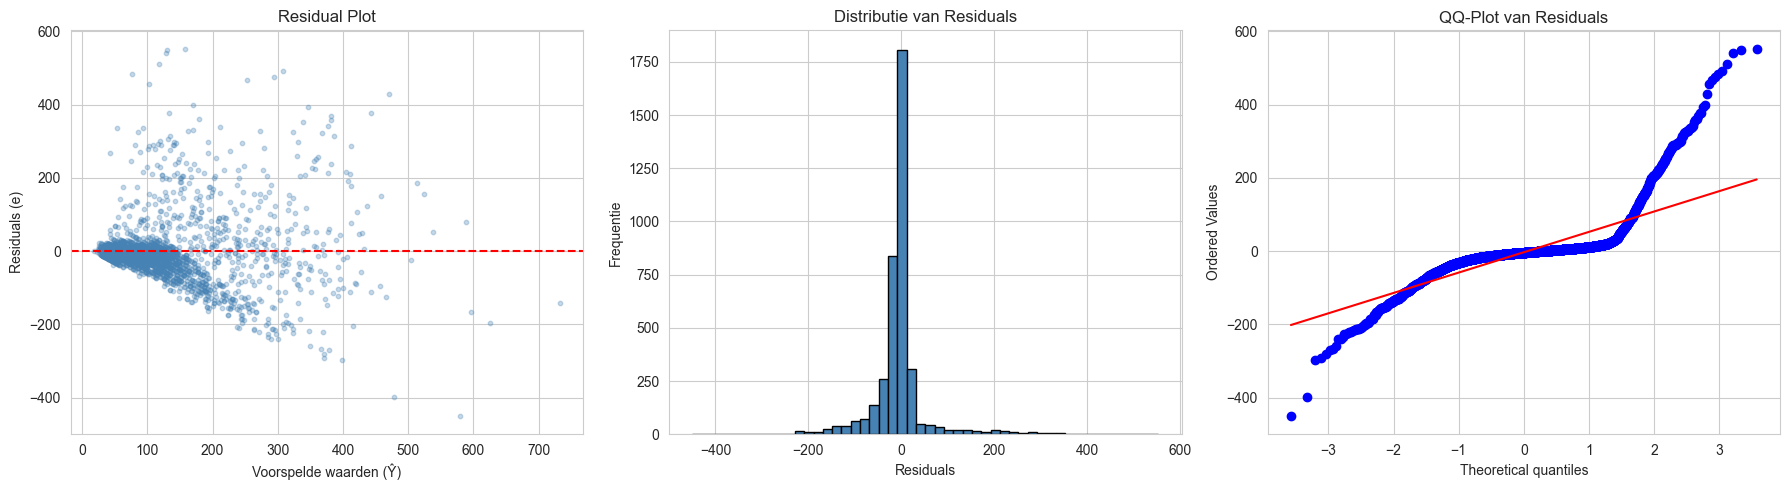

Gemiddelde residual: -2.76
Std residual: 67.46


In [17]:
# Residuals berekenen voor Random Forest
best_model = models['Random Forest']
y_pred_rf = best_model.predict(X_test)
residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residual plot: voorspelde waarden vs residuals
axes[0].scatter(y_pred_rf, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residual Plot')
axes[0].set_xlabel('Voorspelde waarden (Ŷ)')
axes[0].set_ylabel('Residuals (e)')

# 2. Histogram van residuals
axes[1].hist(residuals, bins=50, edgecolor='black', color='steelblue')
axes[1].set_title('Distributie van Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequentie')

# 3. QQ-plot voor normaliteit
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('QQ-Plot van Residuals')

plt.tight_layout()
plt.show()

# Samenvatting
print(f"Gemiddelde residual: {residuals.mean():.2f}")
print(f"Std residual: {residuals.std():.2f}")

### Bevinding: Residual Analysis

**Residual Plot:** Bij hogere voorspelde waarden worden de fouten groter (trechter-vorm). 
Dit heet **heteroscedasticity** — de fouten zijn niet gelijk verdeeld over alle voorspellingen. 
Dit is niet ideaal, maar voor Random Forest is het acceptabel.

**Distributie:** De meeste fouten liggen rond 0 (goed), maar er zijn uitschieters tot +600. 
De verdeling is scheef en niet normaal.

**QQ-Plot:** De punten wijken aan beide uiteinden af van de diagonale lijn. 
Dit bevestigt dat de fouten niet normaal verdeeld zijn.

**Gemiddelde residual:** -2.76 (dicht bij 0, dus het model over- of onderschat niet systematisch).

**Conclusie:** De residuals zijn niet perfect — de fouten worden groter bij hogere voorspellingen 
en zijn niet normaal verdeeld. Dit komt door de scheve verdeling van de target variabele. 
Random Forest is desondanks het beste model, omdat het — anders dan lineaire regressie — 
geen aanname maakt over de verdeling van de fouten.

## 7. Model Retrain en Opslaan

Het beste model (Random Forest) wordt opnieuw getraind op de volledige trainingsdata 
en opgeslagen met joblib. We slaan ook de lijst van gebruikte features op, 
zodat de Streamlit app later weet welke input nodig is.

In [18]:
import joblib

# Beste model opnieuw trainen op volledige trainingsdata
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

# Controleer prestaties op testset
y_pred_final = final_model.predict(X_test)
r2_final = r2_score(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f"Final Model - R²: {r2_final:.4f}")
print(f"Final Model - RMSE: {rmse_final:.2f}")

Final Model - R²: 0.5446
Final Model - RMSE: 67.51


In [19]:
# Model opslaan
joblib.dump(final_model, '../models/model.joblib')
print("Model opgeslagen als: models/model.joblib")

# Feature-namen opslaan (nodig voor de Streamlit app)
joblib.dump(selected_features, '../models/features.joblib')
print("Feature-namen opgeslagen als: models/features.joblib")

# Check bestandsgrootte
import os
model_size = os.path.getsize('../models/model.joblib') / (1024 * 1024)
print(f"\nModelgrootte: {model_size:.2f} MB")

Model opgeslagen als: models/model.joblib
Feature-namen opgeslagen als: models/features.joblib

Modelgrootte: 95.40 MB
